In [2]:
import numpy as np
image = np.array([
    [3, 4, 5, 6],
    [2, 3, 4, 5],
    [1, 2, 3, 4],
    [0, 1, 2, 3]
])
print("Original Image:\n")
print(image)
L = 16
hist = np.zeros(L, dtype=int)

for pixel in image.flatten():
    hist[pixel] += 1

print("\nHistogram:")
for i in range(L):
    print(f"Gray Level {i}: {hist[i]}")

total_pixels = image.size
pdf = hist / total_pixels

print("\nProbability Distribution:")
for i in range(L):
    print(f"P({i}) = {pdf[i]:.4f}")
cdf = np.cumsum(pdf)

print("\nCDF:")
for i in range(L):
    print(f"CDF({i}) = {cdf[i]:.4f}")
mapping = np.floor((L - 1) * cdf).astype(int)

print("\nEqualization Mapping:")
for i in range(L):
    print(f"{i} --> {mapping[i]}")
equalized_image = np.zeros_like(image)

for i in range(image.shape[0]):
    for j in range(image.shape[1]):
        equalized_image[i, j] = mapping[image[i, j]]
print("\nEqualized Image:\n")
print(equalized_image)

Original Image:

[[3 4 5 6]
 [2 3 4 5]
 [1 2 3 4]
 [0 1 2 3]]

Histogram:
Gray Level 0: 1
Gray Level 1: 2
Gray Level 2: 3
Gray Level 3: 4
Gray Level 4: 3
Gray Level 5: 2
Gray Level 6: 1
Gray Level 7: 0
Gray Level 8: 0
Gray Level 9: 0
Gray Level 10: 0
Gray Level 11: 0
Gray Level 12: 0
Gray Level 13: 0
Gray Level 14: 0
Gray Level 15: 0

Probability Distribution:
P(0) = 0.0625
P(1) = 0.1250
P(2) = 0.1875
P(3) = 0.2500
P(4) = 0.1875
P(5) = 0.1250
P(6) = 0.0625
P(7) = 0.0000
P(8) = 0.0000
P(9) = 0.0000
P(10) = 0.0000
P(11) = 0.0000
P(12) = 0.0000
P(13) = 0.0000
P(14) = 0.0000
P(15) = 0.0000

CDF:
CDF(0) = 0.0625
CDF(1) = 0.1875
CDF(2) = 0.3750
CDF(3) = 0.6250
CDF(4) = 0.8125
CDF(5) = 0.9375
CDF(6) = 1.0000
CDF(7) = 1.0000
CDF(8) = 1.0000
CDF(9) = 1.0000
CDF(10) = 1.0000
CDF(11) = 1.0000
CDF(12) = 1.0000
CDF(13) = 1.0000
CDF(14) = 1.0000
CDF(15) = 1.0000

Equalization Mapping:
0 --> 0
1 --> 2
2 --> 5
3 --> 9
4 --> 12
5 --> 14
6 --> 15
7 --> 15
8 --> 15
9 --> 15
10 --> 15
11 --> 15
12 --> 15


/tmp/ipykernel_3839/1650121339.py:16: RuntimeWarning: overflow encountered in scalar add
  c = 255 / np.log(1 + np.max(image))
/tmp/ipykernel_3839/1650121339.py:16: RuntimeWarning: divide by zero encountered in log
  c = 255 / np.log(1 + np.max(image))


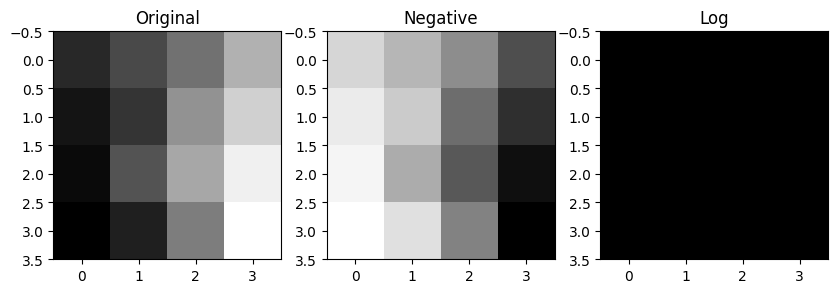

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Sample grayscale image
image = np.array([
    [50, 80, 120, 180],
    [30, 60, 150, 210],
    [20, 90, 170, 240],
    [10, 40, 130, 255]
], dtype=np.uint8)

# Negative Transformation
negative = 255 - image

# Log Transformation
c = 255 / np.log(1 + np.max(image))
log_image = c * np.log(1 + image.astype(np.float32))
log_image = np.uint8(log_image)

# Display
plt.figure(figsize=(10,4))

plt.subplot(1,3,1)
plt.imshow(image, cmap='gray')
plt.title("Original")

plt.subplot(1,3,2)
plt.imshow(negative, cmap='gray')
plt.title("Negative")

plt.subplot(1,3,3)
plt.imshow(log_image, cmap='gray')
plt.title("Log")

plt.show()

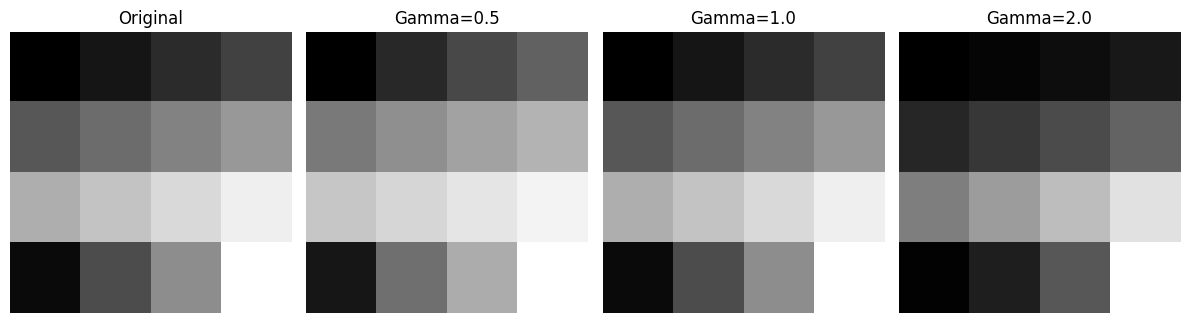

In [1]:
import numpy as np
import matplotlib.pyplot as plt

image = np.array([
    [20, 40, 60, 80],
    [100, 120, 140, 160],
    [180, 200, 220, 240],
    [30, 90, 150, 255]
], dtype=np.uint8)

image_norm = image / 255.0

gamma_values = [0.5, 1.0, 2.0]

plt.figure(figsize=(12,4))

plt.subplot(1,4,1)
plt.imshow(image, cmap='gray')
plt.title("Original")
plt.axis('off')


for i, gamma in enumerate(gamma_values):

    gamma_image = np.power(image_norm, gamma)
    gamma_image = (gamma_image * 255).astype(np.uint8)

    plt.subplot(1,4,i+2)
    plt.imshow(gamma_image, cmap='gray')
    plt.title(f"Gamma={gamma}")
    plt.axis('off')

plt.tight_layout()
plt.show()

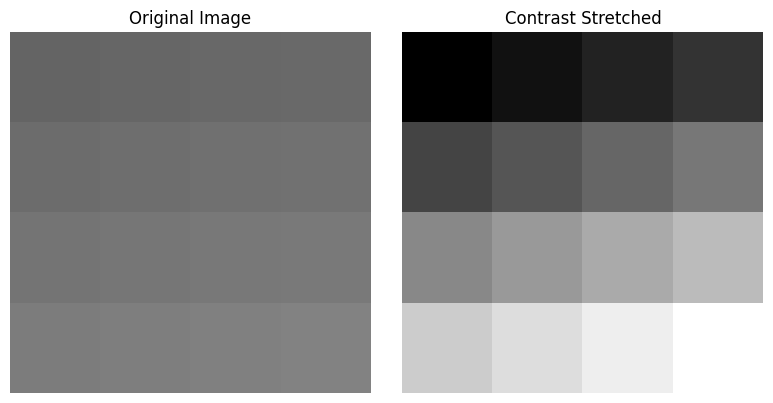

Original Image:
[[100 102 104 106]
 [108 110 112 114]
 [116 118 120 122]
 [124 126 128 130]]

Contrast Stretched Image:
[[  0  17  34  51]
 [ 68  85 102 119]
 [136 153 170 187]
 [204 221 238 255]]


In [2]:
import numpy as np
import matplotlib.pyplot as plt

image = np.array([
    [100, 102, 104, 106],
    [108, 110, 112, 114],
    [116, 118, 120, 122],
    [124, 126, 128, 130]
], dtype=np.uint8)


r1 = 100
r2 = 130

s1 = 0
s2 = 255

stretched = np.zeros_like(image, dtype=np.uint8)

rows, cols = image.shape

for i in range(rows):
    for j in range(cols):

        r = image[i, j]

        if r <= r1:
            s = (s1 / r1) * r if r1 != 0 else 0

        elif r <= r2:
            s = ((s2 - s1) / (r2 - r1)) * (r - r1) + s1

        else:
            s = ((255 - s2) / (255 - r2)) * (r - r2) + s2

        stretched[i, j] = np.clip(s, 0, 255)


plt.figure(figsize=(8,4))

plt.subplot(1,2,1)
plt.imshow(image, cmap='gray', vmin=0, vmax=255)
plt.title("Original Image")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(stretched, cmap='gray', vmin=0, vmax=255)
plt.title("Contrast Stretched")
plt.axis('off')

plt.tight_layout()
plt.show()

print("Original Image:")
print(image)

print("\nContrast Stretched Image:")
print(stretched)

In [3]:
import numpy as np


image = np.array([
    [10, 20, 30, 40, 50],
    [15, 25, 35, 45, 55],
    [20, 30, 40, 50, 60],
    [25, 35, 45, 55, 65],
    [30, 40, 50, 60, 70]
], dtype=np.float32)


kernel = np.ones((3,3), dtype=np.float32) / 9

rows, cols = image.shape
output = np.zeros((rows-2, cols-2))

for i in range(rows-2):
    for j in range(cols-2):
        region = image[i:i+3, j:j+3]
        output[i,j] = np.sum(region * kernel)


print("Original Image (5x5):")
print(image)

print("\nMean Filter Kernel:")
print(kernel)

print("\nFiltered Image:")
print(output)

Original Image (5x5):
[[10. 20. 30. 40. 50.]
 [15. 25. 35. 45. 55.]
 [20. 30. 40. 50. 60.]
 [25. 35. 45. 55. 65.]
 [30. 40. 50. 60. 70.]]

Mean Filter Kernel:
[[0.11111111 0.11111111 0.11111111]
 [0.11111111 0.11111111 0.11111111]
 [0.11111111 0.11111111 0.11111111]]

Filtered Image:
[[25.00000191 35.00000381 45.        ]
 [30.         40.         50.        ]
 [35.00000381 45.         55.        ]]


In [4]:
import numpy as np

image = np.array([
    [10, 20, 30, 40, 50],
    [15, 255, 35, 0, 55],
    [20, 30, 40, 50, 60],
    [25, 0, 45, 255, 65],
    [30, 40, 50, 60, 70]
], dtype=np.uint8)

rows, cols = image.shape
output = image.copy()

for i in range(1, rows - 1):
    for j in range(1, cols - 1):
        window = image[i-1:i+2, j-1:j+2]
        output[i, j] = np.median(window)

print("Original Image:")
print(image)

print("\nMedian Filtered Image:")
print(output)

Original Image:
[[ 10  20  30  40  50]
 [ 15 255  35   0  55]
 [ 20  30  40  50  60]
 [ 25   0  45 255  65]
 [ 30  40  50  60  70]]

Median Filtered Image:
[[10 20 30 40 50]
 [15 30 35 40 55]
 [20 30 40 50 60]
 [25 30 45 60 65]
 [30 40 50 60 70]]


In [5]:
import numpy as np

image = np.array([
    [10, 20, 30, 40, 50],
    [20, 30, 40, 50, 60],
    [30, 40, 50, 60, 70],
    [40, 50, 60, 70, 80],
    [50, 60, 70, 80, 90]
], dtype=np.int32)

kernel = np.array([
    [0, -1, 0],
    [-1, 4, -1],
    [0, -1, 0]
])

rows, cols = image.shape
laplacian = np.zeros((rows-2, cols-2), dtype=np.int32)

for i in range(rows-2):
    for j in range(cols-2):
        laplacian[i, j] = np.sum(image[i:i+3, j:j+3] * kernel)

sharpened = image[1:4, 1:4] - laplacian
sharpened = np.clip(sharpened, 0, 255)

print("Original Image:")
print(image)

print("\nLaplacian Image:")
print(laplacian)

print("\nSharpened Image:")
print(sharpened)

Original Image:
[[10 20 30 40 50]
 [20 30 40 50 60]
 [30 40 50 60 70]
 [40 50 60 70 80]
 [50 60 70 80 90]]

Laplacian Image:
[[0 0 0]
 [0 0 0]
 [0 0 0]]

Sharpened Image:
[[30 40 50]
 [40 50 60]
 [50 60 70]]


In [6]:
import numpy as np

image = np.array([
    [10, 20, 30, 40, 50],
    [20, 30, 40, 50, 60],
    [30, 40, 50, 60, 70],
    [40, 50, 60, 70, 80],
    [50, 60, 70, 80, 90]
], dtype=np.float32)

kernel = np.ones((3, 3), dtype=np.float32) / 9

rows, cols = image.shape
blur = np.zeros((rows - 2, cols - 2))

for i in range(rows - 2):
    for j in range(cols - 2):
        blur[i, j] = np.sum(image[i:i+3, j:j+3] * kernel)

original = image[1:4, 1:4]
mask = original - blur

A = 1.5
high_boost = original + A * mask
high_boost = np.clip(high_boost, 0, 255)

print("Original Image:")
print(image)

print("\nBlurred Image:")
print(blur)

print("\nMask:")
print(mask)

print("\nHigh-Boost Filtered Image:")
print(high_boost.astype(np.uint8))

Original Image:
[[10. 20. 30. 40. 50.]
 [20. 30. 40. 50. 60.]
 [30. 40. 50. 60. 70.]
 [40. 50. 60. 70. 80.]
 [50. 60. 70. 80. 90.]]

Blurred Image:
[[30. 40. 50.]
 [40. 50. 60.]
 [50. 60. 70.]]

Mask:
[[0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]]

High-Boost Filtered Image:
[[30 40 50]
 [40 50 60]
 [50 60 70]]


Original Image:
[[10. 20. 30. 40. 50.]
 [20. 30. 40. 50. 60.]
 [30. 40. 50. 60. 70.]
 [40. 50. 60. 70. 80.]
 [50. 60. 70. 80. 90.]]

Ideal Low-Pass Filter Mask:
[[0. 0. 0. 0. 0.]
 [0. 0. 1. 0. 0.]
 [0. 1. 1. 1. 0.]
 [0. 0. 1. 0. 0.]
 [0. 0. 0. 0. 0.]]

Filtered Image:
[[30.   23.82 40.   56.18 50.  ]
 [23.82 17.64 33.82 50.   43.82]
 [40.   33.82 50.   66.18 60.  ]
 [56.18 50.   66.18 82.36 76.18]
 [50.   43.82 60.   76.18 70.  ]]


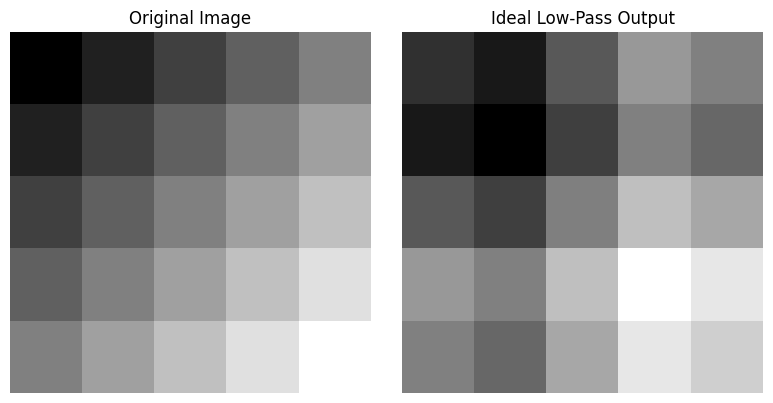

In [7]:
import numpy as np
import matplotlib.pyplot as plt

image = np.array([
    [10, 20, 30, 40, 50],
    [20, 30, 40, 50, 60],
    [30, 40, 50, 60, 70],
    [40, 50, 60, 70, 80],
    [50, 60, 70, 80, 90]
], dtype=np.float32)

F = np.fft.fft2(image)
F_shift = np.fft.fftshift(F)

rows, cols = image.shape
crow, ccol = rows // 2, cols // 2

D0 = 1

mask = np.zeros((rows, cols))

for i in range(rows):
    for j in range(cols):
        D = np.sqrt((i - crow)**2 + (j - ccol)**2)
        if D <= D0:
            mask[i, j] = 1

G = F_shift * mask

G_shift = np.fft.ifftshift(G)
filtered = np.fft.ifft2(G_shift)
filtered = np.abs(filtered)

print("Original Image:")
print(image)

print("\nIdeal Low-Pass Filter Mask:")
print(mask)

print("\nFiltered Image:")
print(np.round(filtered, 2))

plt.figure(figsize=(8,4))

plt.subplot(1,2,1)
plt.imshow(image, cmap='gray')
plt.title("Original Image")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(filtered, cmap='gray')
plt.title("Ideal Low-Pass Output")
plt.axis('off')

plt.tight_layout()
plt.show()

Original Image:
[[10. 20. 30. 40. 50.]
 [20. 30. 40. 50. 60.]
 [30. 40. 50. 60. 70.]
 [40. 50. 60. 70. 80.]
 [50. 60. 70. 80. 90.]]

Gaussian High-Pass Filter:
[[0.831 0.671 0.589 0.671 0.831]
 [0.671 0.359 0.199 0.359 0.671]
 [0.589 0.199 0.    0.199 0.589]
 [0.671 0.359 0.199 0.359 0.671]
 [0.831 0.671 0.589 0.671 0.831]]

Filtered Image:
[[15.76  7.47  7.88  8.3   0.  ]
 [ 7.47  0.83  0.42  0.    8.3 ]
 [ 7.88  0.42  0.    0.42  7.88]
 [ 8.3   0.    0.42  0.83  7.47]
 [ 0.    8.3   7.88  7.47 15.76]]


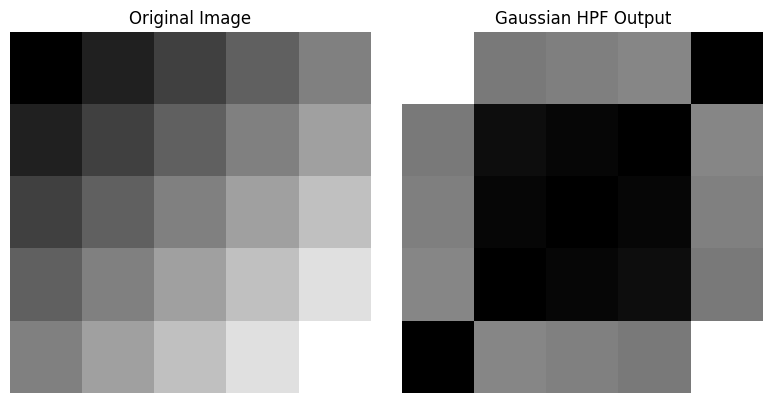

In [8]:
import numpy as np
import matplotlib.pyplot as plt

image = np.array([
    [10, 20, 30, 40, 50],
    [20, 30, 40, 50, 60],
    [30, 40, 50, 60, 70],
    [40, 50, 60, 70, 80],
    [50, 60, 70, 80, 90]
], dtype=np.float32)

F = np.fft.fft2(image)
F_shift = np.fft.fftshift(F)

rows, cols = image.shape
crow, ccol = rows // 2, cols // 2

D0 = 1.5

H = np.zeros((rows, cols))

for i in range(rows):
    for j in range(cols):
        D = np.sqrt((i - crow) ** 2 + (j - ccol) ** 2)
        H[i, j] = 1 - np.exp(-(D ** 2) / (2 * (D0 ** 2)))

G = F_shift * H

result = np.fft.ifft2(np.fft.ifftshift(G))
result = np.abs(result)

print("Original Image:")
print(image)

print("\nGaussian High-Pass Filter:")
print(np.round(H, 3))

print("\nFiltered Image:")
print(np.round(result, 2))

plt.figure(figsize=(8,4))

plt.subplot(1,2,1)
plt.imshow(image, cmap="gray")
plt.title("Original Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(result, cmap="gray")
plt.title("Gaussian HPF Output")
plt.axis("off")

plt.tight_layout()
plt.show()

In [9]:
import numpy as np

image = np.array([
    [10, 10, 10, 10, 10],
    [10, 10, 10, 10, 10],
    [10, 10, 255, 10, 10],
    [10, 10, 10, 10, 10],
    [10, 10, 10, 10, 10]
], dtype=np.int32)

mask = np.array([
    [-1, -1, -1],
    [-1,  8, -1],
    [-1, -1, -1]
])

rows, cols = image.shape
output = np.zeros((rows - 2, cols - 2), dtype=np.int32)

for i in range(rows - 2):
    for j in range(cols - 2):
        output[i, j] = np.sum(image[i:i+3, j:j+3] * mask)

threshold = 200

points = np.where(output > threshold, 255, 0)

print("Original Image:")
print(image)

print("\nLaplacian Response:")
print(output)

print("\nDetected Points:")
print(points)

Original Image:
[[ 10  10  10  10  10]
 [ 10  10  10  10  10]
 [ 10  10 255  10  10]
 [ 10  10  10  10  10]
 [ 10  10  10  10  10]]

Laplacian Response:
[[-245 -245 -245]
 [-245 1960 -245]
 [-245 -245 -245]]

Detected Points:
[[  0   0   0]
 [  0 255   0]
 [  0   0   0]]


In [10]:
import numpy as np

image = np.array([
    [10, 10, 10, 10, 10],
    [10, 50, 50, 50, 10],
    [10, 50, 90, 50, 10],
    [10, 50, 50, 50, 10],
    [10, 10, 10, 10, 10]
], dtype=np.int32)

horizontal = np.array([
    [-1, -1, -1],
    [ 2,  2,  2],
    [-1, -1, -1]
])

vertical = np.array([
    [-1, 2, -1],
    [-1, 2, -1],
    [-1, 2, -1]
])

plus45 = np.array([
    [-1, -1, 2],
    [-1, 2, -1],
    [2, -1, -1]
])

minus45 = np.array([
    [2, -1, -1],
    [-1, 2, -1],
    [-1, -1, 2]
])

rows, cols = image.shape

def convolve(img, kernel):
    output = np.zeros((rows - 2, cols - 2), dtype=np.int32)
    for i in range(rows - 2):
        for j in range(cols - 2):
            output[i, j] = np.sum(img[i:i+3, j:j+3] * kernel)
    return output

h = convolve(image, horizontal)
v = convolve(image, vertical)
p45 = convolve(image, plus45)
m45 = convolve(image, minus45)

print("Original Image:")
print(image)

print("\nHorizontal Line Detection:")
print(h)

print("\nVertical Line Detection:")
print(v)

print("\n+45° Line Detection:")
print(p45)

print("\n-45° Line Detection:")
print(m45)

Original Image:
[[10 10 10 10 10]
 [10 50 50 50 10]
 [10 50 90 50 10]
 [10 50 50 50 10]
 [10 10 10 10 10]]

Horizontal Line Detection:
[[40 80 40]
 [80 80 80]
 [40 80 40]]

Vertical Line Detection:
[[40 80 40]
 [80 80 80]
 [40 80 40]]

+45° Line Detection:
[[-80 -40 160]
 [-40  80 -40]
 [160 -40 -80]]

-45° Line Detection:
[[160 -40 -80]
 [-40  80 -40]
 [-80 -40 160]]


In [11]:
import numpy as np

image = np.array([
    [20, 22, 25, 28, 30],
    [35, 40, 42, 45, 50],
    [120, 125, 130, 135, 140],
    [145, 150, 155, 160, 165],
    [170, 175, 180, 185, 190]
], dtype=np.uint8)

hist = np.bincount(image.ravel(), minlength=256)

total = image.size
sum_total = np.sum(np.arange(256) * hist)

sumB = 0
wB = 0
maximum = 0
threshold = 0

for t in range(256):
    wB += hist[t]
    if wB == 0:
        continue

    wF = total - wB
    if wF == 0:
        break

    sumB += t * hist[t]

    mB = sumB / wB
    mF = (sum_total - sumB) / wF

    variance = wB * wF * (mB - mF) ** 2

    if variance > maximum:
        maximum = variance
        threshold = t

binary = np.where(image > threshold, 255, 0)

print("Optimal Threshold:", threshold)

print("\nOriginal Image:")
print(image)

print("\nBinary Image:")
print(binary)

Optimal Threshold: 50

Original Image:
[[ 20  22  25  28  30]
 [ 35  40  42  45  50]
 [120 125 130 135 140]
 [145 150 155 160 165]
 [170 175 180 185 190]]

Binary Image:
[[  0   0   0   0   0]
 [  0   0   0   0   0]
 [255 255 255 255 255]
 [255 255 255 255 255]
 [255 255 255 255 255]]


In [12]:
import numpy as np

image = np.array([
    [10, 10, 12, 80, 82],
    [10, 11, 13, 81, 83],
    [12, 12, 15, 82, 84],
    [90, 91, 92, 20, 21],
    [91, 92, 93, 22, 23]
], dtype=np.uint8)

seed = (1, 1)
threshold = 5

rows, cols = image.shape
segmented = np.zeros((rows, cols), dtype=np.uint8)
visited = np.zeros((rows, cols), dtype=bool)

stack = [seed]
seed_value = image[seed]

while stack:
    x, y = stack.pop()

    if x < 0 or x >= rows or y < 0 or y >= cols:
        continue

    if visited[x, y]:
        continue

    visited[x, y] = True

    if abs(int(image[x, y]) - int(seed_value)) <= threshold:
        segmented[x, y] = 255

        stack.append((x-1, y))
        stack.append((x+1, y))
        stack.append((x, y-1))
        stack.append((x, y+1))

print("Original Image:")
print(image)

print("\nSegmented Image:")
print(segmented)

Original Image:
[[10 10 12 80 82]
 [10 11 13 81 83]
 [12 12 15 82 84]
 [90 91 92 20 21]
 [91 92 93 22 23]]

Segmented Image:
[[255 255 255   0   0]
 [255 255 255   0   0]
 [255 255 255   0   0]
 [  0   0   0   0   0]
 [  0   0   0   0   0]]


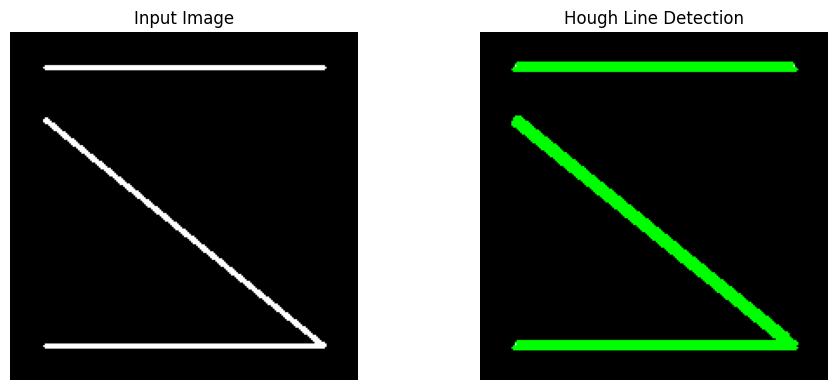

In [13]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

image = np.zeros((200, 200), dtype=np.uint8)

cv2.line(image, (20, 20), (180, 20), 255, 2)
cv2.line(image, (20, 50), (180, 180), 255, 2)
cv2.line(image, (20, 180), (180, 180), 255, 2)

edges = cv2.Canny(image, 50, 150)

lines = cv2.HoughLinesP(
    edges,
    1,
    np.pi / 180,
    threshold=30,
    minLineLength=30,
    maxLineGap=10
)

result = cv2.cvtColor(image, cv2.COLOR_GRAY2BGR)

if lines is not None:
    for line in lines:
        x1, y1, x2, y2 = line[0]
        cv2.line(result, (x1, y1), (x2, y2), (0, 255, 0), 2)

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(image, cmap="gray")
plt.title("Input Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(cv2.cvtColor(result, cv2.COLOR_BGR2RGB))
plt.title("Hough Line Detection")
plt.axis("off")

plt.tight_layout()
plt.show()